# Gen AI-Powered Image Captioning: Automating Image Descriptions 

## Objective  
To develop an AI-powered system capable of generating accurate and context-aware captions for images using generative models.



## Test Image

- Download the given image in your device.
- Use this to generate caption with your model.

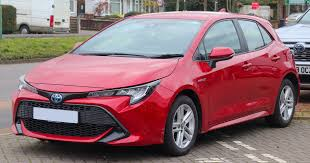

In [1]:
import gradio as gr
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import warnings
warnings.filterwarnings("ignore")

In [2]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

In [3]:
def generate_caption(image):
    raw_image = Image.open(image).convert('RGB')
    inputs = processor(images=raw_image, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    return caption

In [4]:
iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs=gr.Textbox(label="Generated Caption"),
    title="Gen AI Powered Image Captioning",
    description="Upload an image and get a caption generated by a pre-trained model."
)

In [5]:
if __name__ == "__main__":
    iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
